In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
!pip install kagglehub
!pip install langdetect
!pip install transformers
!pip install datasets
!pip install -q wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.7 MB/s eta 0:00:00:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=c1be36fa90dce99f3aa260fdfc6bcc441b72a78d9f59b4e8487842d7f4391c34
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.12.0 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platf

In [140]:
# Disable W&B logging for clean ouput
import os
# os.environ["WANDB_DISABLED"] = "false"
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")
# wandb.login(key=api_key)
os.environ["WANDB_API_KEY"] = api_key
os.environ["WANDB_PROJECT"] = 'nlp'
# os.environ.get("WANDB_PROJECT")
# os.environ.get("WANDB_API_KEY")
# wandb.init()
# wandb.config.clear() 

import re
import wandb
import kagglehub
import numpy as np
import pandas as pd
from langdetect import detect
from sklearn.model_selection import train_test_split
from transformers import DistilBertConfig, DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments,get_scheduler
# from torch.utils.data import Dataset
from datasets import DatasetDict, Dataset
from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score, confusion_matrix, classification_report
import torch.nn as nn
import torch
from sklearn.utils.class_weight import compute_class_weight
# roc_auc_score
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [4]:
# Download dataset
def load_dataset(used_column):
    dataset_path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")
    print("dataset downloaded to this path:", dataset_path)
    ds = pd.read_csv(os.path.join(dataset_path,'aa_dataset-tickets-multi-lang-5-2-50-version.csv'),usecols=used_column)
    ds = ds.rename(columns={'queue': 'label'})
    return ds

In [131]:
def cleanse_text(text):
    if not isinstance(text, str):
        return ""
        
    # Replace multiple newlines or excessive spaces
    text = text.replace("\\n", " ")
    # text = text.replace("\n", " ")
    
    return text

In [174]:
# Retain necessary columns
used_column = ['body','queue','language','subject'] #['type','queue','priority']
ds = load_dataset(used_column)

# Check null label value, and discard the value
if ds['label'].isnull().any():
    print('There are some rows that has null label value, discard the rows')
    ds = ds.dropna(subset=['label'])

# cleansing the text
ds["body"] = ds['body'].apply(cleanse_text)

# We use the langdetect library to label the language used in the text
# ds['lang'] = ds['body'].apply(lambda x: detect(str(x)))

# Discard non english text
ds = ds[ds['language'] == 'en']
ds = ds.drop(columns=['language'])#.reset_index(drop=False)

# Display labels
print('Unique value for category:', ds['label'].unique())
# Check label distribution
print('Label freq:', ds['label'].value_counts(normalize=True) * 100)
# Display total row number for each label
print('Label freq:', ds['label'].value_counts())

# Enumerate categories
label2id = {label: idx for idx, label in enumerate(ds['label'].unique())}
ds['label'] = ds['label'].map(label2id)

# reverse
id2label = {v: k for k, v in label2id.items()}

dataset downloaded to this path: /kaggle/input/multilingual-customer-support-tickets
Unique value for category: ['Technical Support' 'Returns and Exchanges' 'Billing and Payments'
 'Sales and Pre-Sales' 'Service Outages and Maintenance' 'Product Support'
 'IT Support' 'Customer Service' 'Human Resources' 'General Inquiry']
Label freq: label
Technical Support                  28.993757
Product Support                    18.808912
Customer Service                   14.750888
IT Support                         11.886400
Billing and Payments                9.762517
Returns and Exchanges               5.018974
Service Outages and Maintenance     4.064145
Sales and Pre-Sales                 3.139919
Human Resources                     2.130004
General Inquiry                     1.444485
Name: proportion, dtype: float64
Label freq: label
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1

In [77]:
# cleanse_text(ds.iloc[2,0])
# print('Clean:',clean_email())
# print('ori',ds.iloc[2,0])
# ds[ds['body']=='']

,body,label


In [78]:
id2label

{0: 'Technical Support',
 1: 'Returns and Exchanges',
 2: 'Billing and Payments',
 3: 'Sales and Pre-Sales',
 4: 'Service Outages and Maintenance',
 5: 'Product Support',
 6: 'IT Support',
 7: 'Customer Service',
 8: 'Human Resources',
 9: 'General Inquiry'}

In [175]:
ds_ready = ds.copy()

# #label map
# label_map = {
#     6: 0,
#     5: 0
# }
# ds_ready["label"] = ds_ready["label"].replace(label_map)

# Split the dataset
train_ds, test_ds = train_test_split(ds_ready, test_size=0.3, random_state=42, stratify=ds_ready['label'])
# Convert to Huggingface dataset object
train_dataset = Dataset.from_pandas(train_ds.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_ds.reset_index(drop=True))
ready_dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [176]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize_function(datas):
    return tokenizer(datas["body"], padding="max_length", truncation=True, max_length=115)

tokenized_dataset = ready_dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

num_labels = train_ds['label'].nunique()
print(num_labels)

Map:   0%|          | 0/11436 [00:00<?, ? examples/s]

Map:   0%|          | 0/4902 [00:00<?, ? examples/s]

10


In [177]:
# model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

def compute_metrics(pred):
    #preds = pred.predictions.argmax(-1)  # Get class with max logit
    logits = pred.predictions
    labels = pred.label_ids

    probs = softmax(logits, axis=1) 
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(labels, preds)

    # Macro
    macro_f1 = f1_score(labels, preds, average='macro')
    # macro_precision = precision_score(labels, preds, average='macro', zero_division=0)
    # macro_recall = recall_score(labels, preds, average='macro', zero_division=0)

    # Weighted
    weighted_f1 = f1_score(labels, preds, average='weighted')
    # weighted_precision = precision_score(labels, preds, average='weighted', zero_division=0)
    # weighted_recall = recall_score(labels, preds, average='weighted', zero_division=0)

    # Multiclass ROC AUC (macro average, One-vs-Rest)
    # try:
    #     roc_auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    # except ValueError:
    #     # Occurs when only one class present in a batch (e.g., small val set)
    #     roc_auc = float("nan")

    # return {
    #     'accuracy': acc,
    #     'macro_f1': macro_f1,
    #     'macro_precision': macro_precision,
    #     'macro_recall': macro_recall,
    #     # "roc_auc": roc_auc,
    #     'weighted_f1': weighted_f1,
    #     'weighted_precision': weighted_precision,
    #     'weighted_recall': weighted_recall
    # }

    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1' : weighted_f1
    }

# Get class weights based on label column
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_ds['label']),
    y=train_ds['label']
)

# Convert to tensor for PyTorch
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0):
        super().__init__()
        self.alpha = alpha  # Class weights
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class DistilBERTWithFocalLoss(DistilBertForSequenceClassification):
    def __init__(self, config, class_weights, gamma=1.0):
        super().__init__(config)
        self.focal = FocalLoss(alpha=class_weights, gamma=gamma)

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss = self.focal(logits, labels)
        return (loss, outputs) if return_outputs else loss

config = DistilBertConfig.from_pretrained("distilbert-base-uncased", num_labels=num_labels,
    id2label=id2label,
    label2id=label2id)
model = DistilBERTWithFocalLoss.from_pretrained(
    "distilbert-base-uncased",
    config=config,
    class_weights=class_weights_tensor
)

# optimizer = trainer.create_optimizer()
# lr_scheduler = get_scheduler(
#     name="linear", optimizer=optimizer,
#     num_warmup_steps=500,
#     num_training_steps=trainer.state.max_steps
# )

Some weights of DistilBERTWithFocalLoss were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [145]:
print(model)
print(model.config)

DistilBERTWithFocalLoss(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            

In [146]:
# for param in model.distilbert.parameters():
#     param.requires_grad = False
    
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")

Trainable: distilbert.embeddings.word_embeddings.weight
Trainable: distilbert.embeddings.position_embeddings.weight
Trainable: distilbert.embeddings.LayerNorm.weight
Trainable: distilbert.embeddings.LayerNorm.bias
Trainable: distilbert.transformer.layer.0.attention.q_lin.weight
Trainable: distilbert.transformer.layer.0.attention.q_lin.bias
Trainable: distilbert.transformer.layer.0.attention.k_lin.weight
Trainable: distilbert.transformer.layer.0.attention.k_lin.bias
Trainable: distilbert.transformer.layer.0.attention.v_lin.weight
Trainable: distilbert.transformer.layer.0.attention.v_lin.bias
Trainable: distilbert.transformer.layer.0.attention.out_lin.weight
Trainable: distilbert.transformer.layer.0.attention.out_lin.bias
Trainable: distilbert.transformer.layer.0.sa_layer_norm.weight
Trainable: distilbert.transformer.layer.0.sa_layer_norm.bias
Trainable: distilbert.transformer.layer.0.ffn.lin1.weight
Trainable: distilbert.transformer.layer.0.ffn.lin1.bias
Trainable: distilbert.transforme

In [178]:
# wandb.init(project="nlp",name="run_3", reinit=False)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    learning_rate=2e-5, 
    logging_dir="./logs",
    logging_steps=5,
    # max_grad_norm=5.0,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="wandb",
    run_name="run_29_macrof1_train_distil_improve_gamma_ratesch",
    warmup_steps=500,  # Add this
    lr_scheduler_type="linear",  # And this
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

print("\nFine-tuning")
trainer.train()

print("\nResult")
trainer_results = trainer.evaluate()       # Evaluate on test set
print(trainer_results)


Fine-tuning


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.665700,1.635531,0.404529,0.242099,0.342474
2,1.276500,1.520921,0.441044,0.328005,0.417651
3,1.284800,1.446935,0.485720,0.384767,0.458728
4,1.250900,1.373747,0.532640,0.426409,0.517025
5,0.902400,1.387462,0.546920,0.458361,0.543021
6,0.712400,1.357683,0.593635,0.489982,0.587000
7,0.433300,1.372034,0.616279,0.512465,0.607241
8,0.637800,1.432153,0.617095,0.532105,0.611411
9,0.366800,1.451205,0.621379,0.550066,0.618358
10,0.201900,1.457880,0.633415,0.554731,0.628073



Result


{'eval_loss': 1.4578803777694702, 'eval_accuracy': 0.6334149326805385, 'eval_macro_f1': 0.5547306861401192, 'eval_weighted_f1': 0.6280731909627947, 'eval_runtime': 8.3497, 'eval_samples_per_second': 587.085, 'eval_steps_per_second': 18.444, 'epoch': 10.0}


In [179]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=10,
#     weight_decay=0.01,
#     learning_rate=1e-5, 
#     logging_dir="./logs",
#     logging_steps=5,
#     max_grad_norm=2.0,
#     load_best_model_at_end=True,
#     metric_for_best_model="weighted_f1",
#     greater_is_better=True,
#     report_to="none"
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_dataset["train"],
#     eval_dataset=tokenized_dataset["test"],
#     compute_metrics=compute_metrics,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )

predictions = trainer.predict(tokenized_dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)
label_names = [label for idx, label in sorted(id2label.items())]
print(classification_report(y_true, y_pred, target_names=label_names, digits=2))

# {'Technical Support': 0,
#  'Returns and Exchanges': 1,
#  'Billing and Payments': 2,
#  'Sales and Pre-Sales': 3,
#  'Service Outages and Maintenance': 4,
#  'Product Support': 5,
#  'IT Support': 6,
#  'Customer Service': 7,
#  'Human Resources': 8,
#  'General Inquiry': 9}

# Technical Support                  28.993757
# Product Support                    18.808912
# Customer Service                   14.750888
# IT Support                         11.886400
# Billing and Payments                9.762517
# Returns and Exchanges               5.018974
# Service Outages and Maintenance     4.064145
# Sales and Pre-Sales                 3.139919
# Human Resources                     2.130004
# General Inquiry                     1.444485

                                 precision    recall  f1-score   support

              Technical Support       0.67      0.71      0.69      1421
          Returns and Exchanges       0.53      0.48      0.50       246
           Billing and Payments       0.83      0.86      0.85       479
            Sales and Pre-Sales       0.46      0.41      0.43       154
Service Outages and Maintenance       0.77      0.76      0.77       199
                Product Support       0.61      0.59      0.60       922
                     IT Support       0.56      0.61      0.58       583
               Customer Service       0.55      0.57      0.56       723
                Human Resources       0.54      0.26      0.35       104
                General Inquiry       0.69      0.13      0.21        71

                       accuracy                           0.63      4902
                      macro avg       0.62      0.54      0.55      4902
                   weighted avg       0.63      0

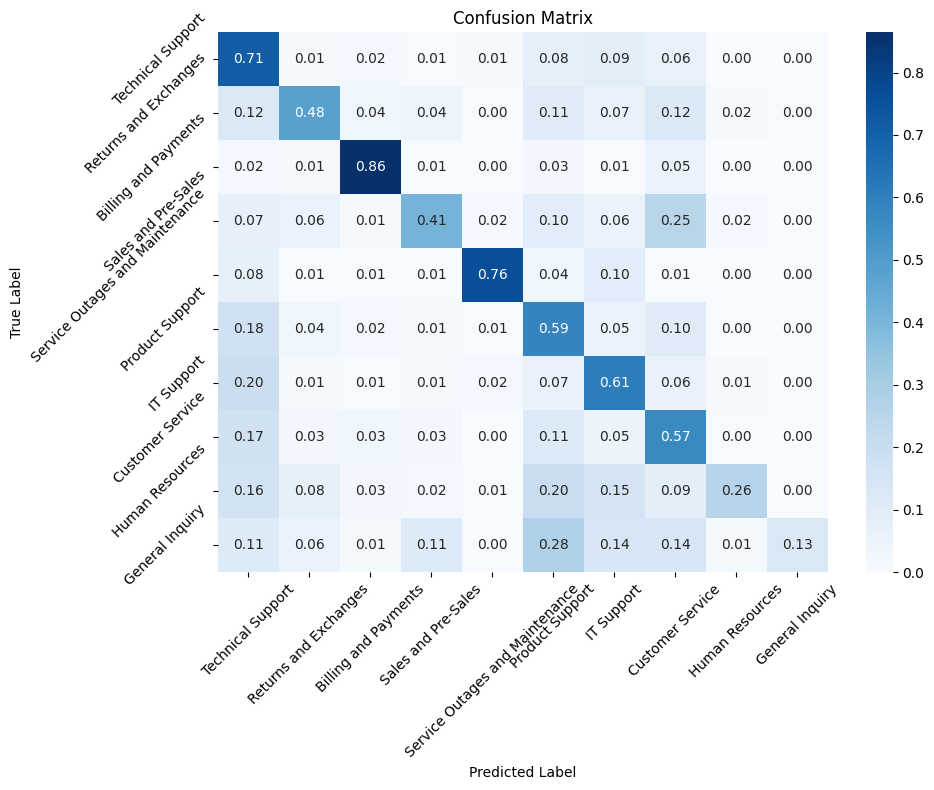

In [180]:
# Count
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)


# Percentage
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
# wandb.log({"confusion_matrix": plt})
plt.show()

In [157]:
wandb.finish()

eval/accuracy,▁▆██
eval/loss,█▃▁▁
eval/macro_f1,▁▆██
eval/runtime,▁▁▁█
eval/samples_per_second,███▁
eval/steps_per_second,███▁
eval/weighted_f1,▁▆██
test/accuracy,▁▁▁
test/loss,▁▁▁
test/macro_f1,▁▁▁
test/runtime,█▁▂


In [ ]:
# !rm -rf /kaggle/working/*